In [1]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from tqdm import tqdm
import numpy as np

from datasets.bcdata import BCDataDataset, collate_heatmap_points
from datasets.transforms import PointsToLocalizationHeatmap, PointsToCountHeatmap


from visualization import overlay_heatmap
from training import train


from models.models import HybridModel
from models.losses import weighted_sigmoid_mse_from_logits, softplus_mse_from_logits, l1_count_from_density_logits

from utils.debug import print_info


import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:
import torch.nn.functional as F


In [3]:

with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)


data_root = Path(cfg["h200_paths"]["data_root"])
checkpoint_dir = Path(cfg["h200_paths"]["checkpoint_dir"])

print(f"data_root: {data_root}")
print(f"checkpoint_dir: {checkpoint_dir}")

data_root: /raid/datasets/Yeldos/BCData
checkpoint_dir: checkpoints


In [4]:
loc_heatmap_generator = PointsToLocalizationHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)
count_heatmap_generator = PointsToCountHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)

train_dataset = BCDataDataset(root = data_root,
                        split="train",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)


test_dataset = BCDataDataset(root = data_root,
                        split="test",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)

val_dataset = BCDataDataset(root = data_root,
                        split="validation",
                        target_loc_transform = loc_heatmap_generator,
                        target_count_transform = count_heatmap_generator)

In [6]:
model = HybridModel()
device = 'cuda'
model.to(device);

In [7]:
model.load_state_dict(torch.load("checkpoints/hybrid_02.pt"))
model.eval();


image: /raid/datasets/Yeldos/BCData/images/train/1.png


gt counts: (40, 41)
predicted counts: tensor([[45.8846, 38.6588]], device='cuda:0', grad_fn=<CatBackward0>)


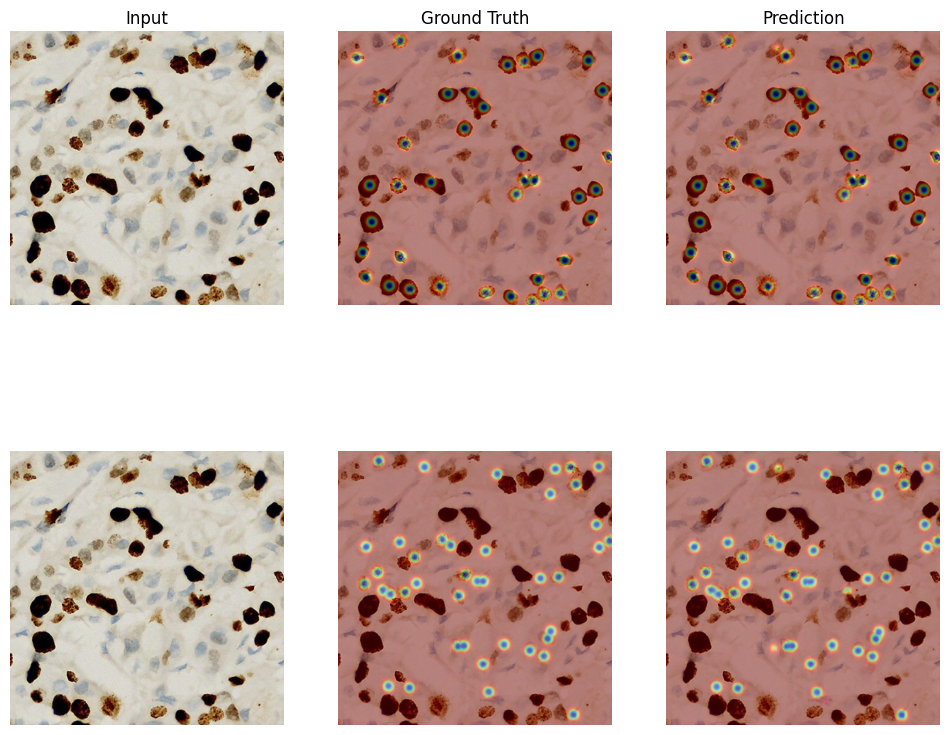

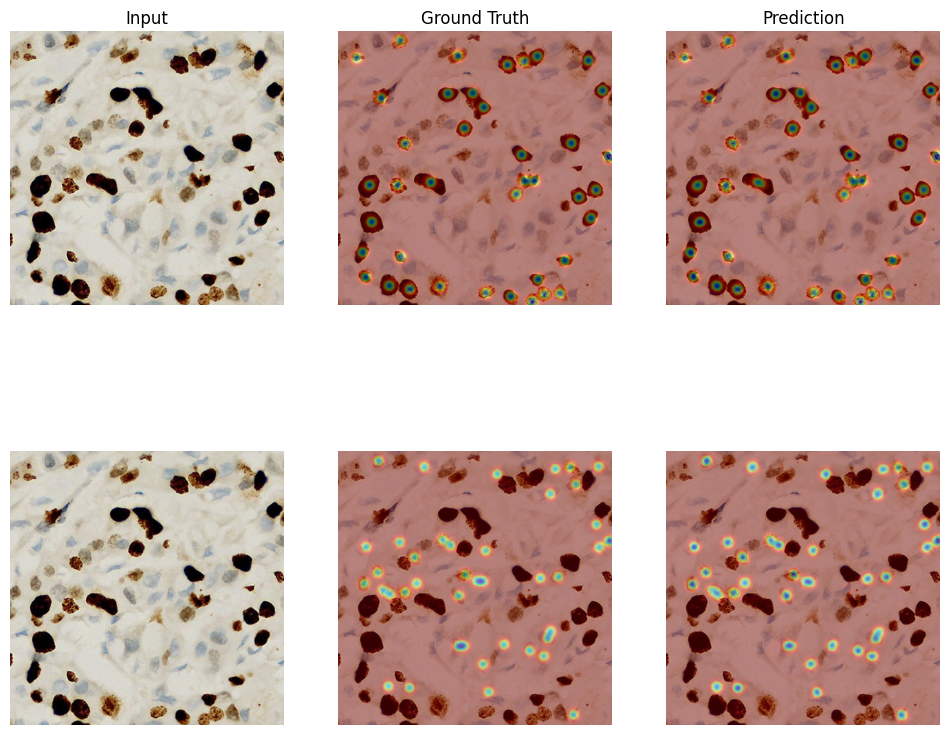

In [8]:
img, loc_heatmap, count_heatmap, pos_pts, neg_pts = train_dataset[1]
img = img.to(device)
loc_heatmap = loc_heatmap.to(device)
count_heatmap = count_heatmap.to(device)

pred_loc_hm, pred_den_hm, pred_count = model(img.unsqueeze(0))
print(f"gt counts: {len(pos_pts), len(neg_pts)}")
print(f"predicted counts: {pred_count}")

alpha = 0.4
overlay_heatmap(img, torch.sigmoid(pred_loc_hm[0]), loc_heatmap, alpha=alpha)
overlay_heatmap(img, F.softplus(pred_den_hm[0]), count_heatmap, alpha=alpha)


image: /raid/datasets/Yeldos/BCData/images/test/368.png


gt counts: (23, 153)
predicted counts: tensor([[ 12.9655, 124.6040]], device='cuda:0', grad_fn=<CatBackward0>)


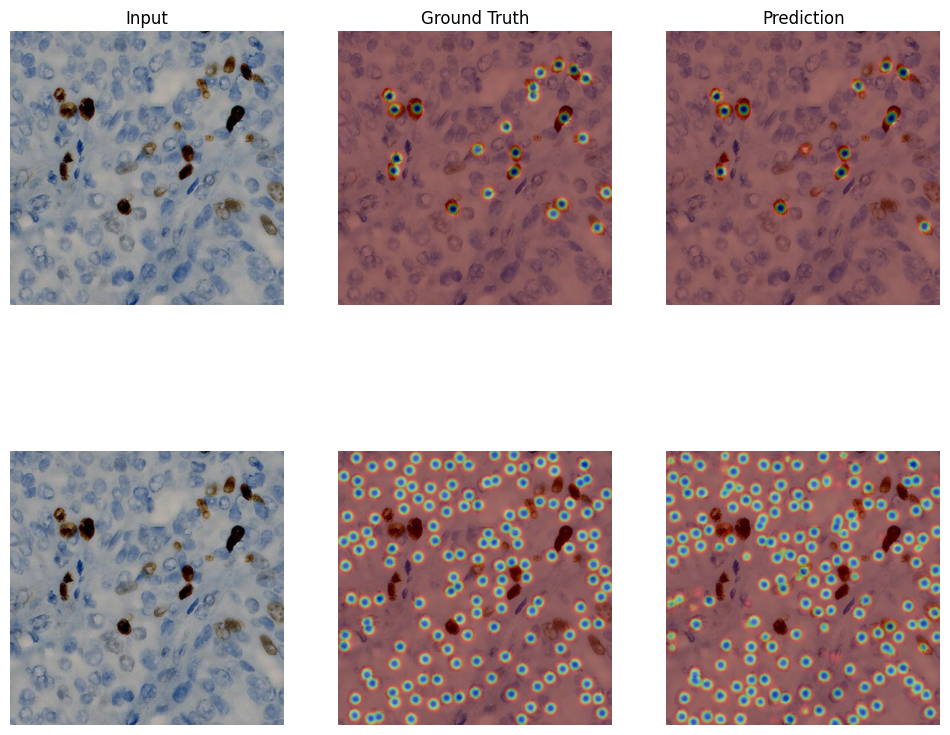

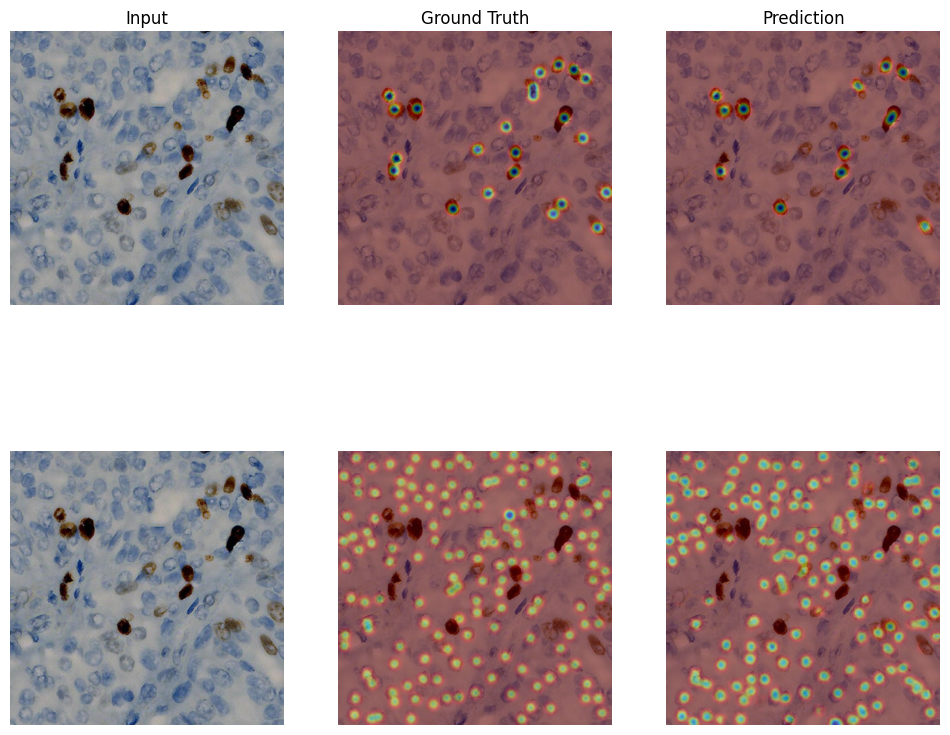

In [10]:
img, loc_heatmap, count_heatmap, pos_pts, neg_pts = test_dataset[299]
img = img.to(device)
loc_heatmap = loc_heatmap.to(device)
count_heatmap = count_heatmap.to(device)

pred_loc_hm, pred_den_hm, pred_count = model(img.unsqueeze(0))
print(f"gt counts: {len(pos_pts), len(neg_pts)}")
print(f"predicted counts: {pred_count}")

alpha = 0.4
overlay_heatmap(img, torch.sigmoid(pred_loc_hm[0]), loc_heatmap, alpha=alpha)
overlay_heatmap(img, F.softplus(pred_den_hm[0]), count_heatmap, alpha=alpha)


image: /raid/datasets/Yeldos/BCData/images/validation/0.png


gt counts: (57, 17)
predicted counts: tensor([[42.9103,  5.9262]], device='cuda:0', grad_fn=<CatBackward0>)


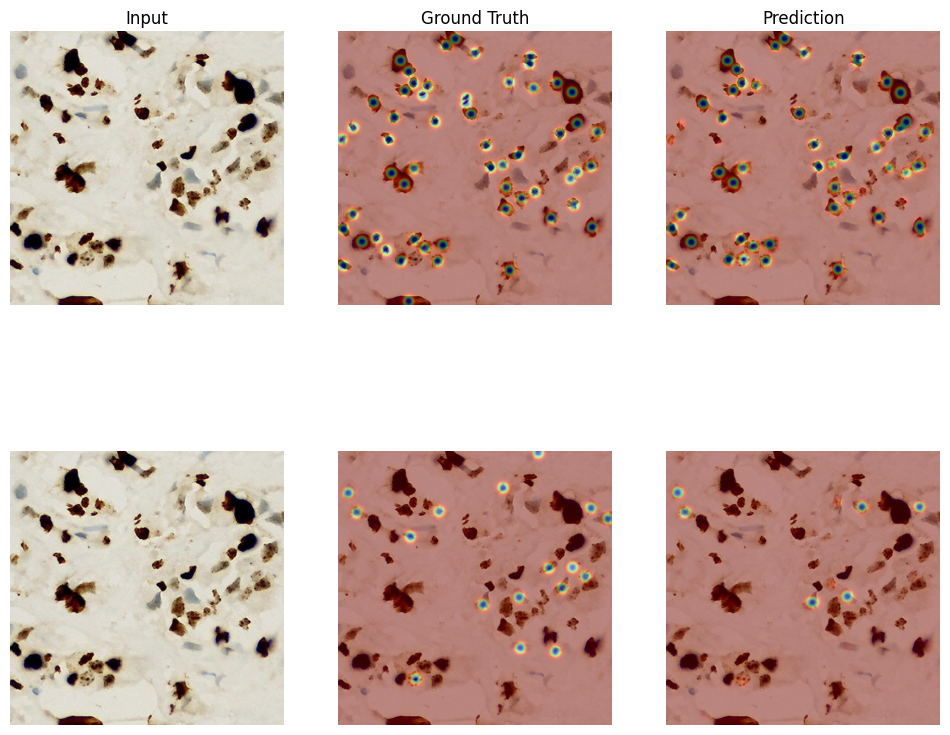

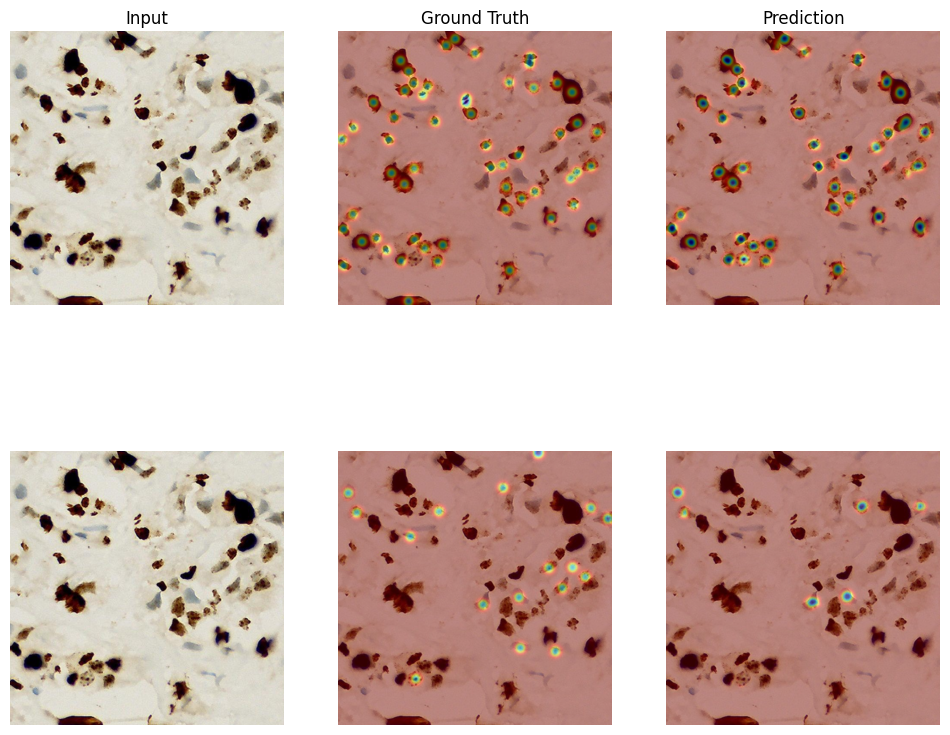

In [12]:
img, loc_heatmap, count_heatmap, pos_pts, neg_pts = val_dataset[0]
img = img.to(device)
loc_heatmap = loc_heatmap.to(device)
count_heatmap = count_heatmap.to(device)

pred_loc_hm, pred_den_hm, pred_count = model(img.unsqueeze(0))
print(f"gt counts: {len(pos_pts), len(neg_pts)}")
print(f"predicted counts: {pred_count}")

alpha = 0.4
overlay_heatmap(img, torch.sigmoid(pred_loc_hm[0]), loc_heatmap, alpha=alpha)
overlay_heatmap(img, F.softplus(pred_den_hm[0]), count_heatmap, alpha=alpha)